In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [46]:
#Train and Test data
transform = transforms.ToTensor()
training_data = datasets.MNIST("./data", train=True, download=True, transform=transform)
testing_data = datasets.MNIST("./data", train=False, download=True, transform=transform)
training_load = DataLoader(training_data, batch_size=64, shuffle=True)
testing_load = DataLoader(testing_data, batch_size=64, shuffle=False)

In [47]:
# In this project, we test 3 models & compare the accuracy: MLP, CNN, Transformer

#1. Transformer
class Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(28, 32)

        layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)

        self.layer2 = nn.Linear(32, 10)

    def forward(self, x):
        x = x.squeeze(1)      
        x = self.layer1(x)       
        x = self.encoder(x)
        x = x.mean(dim=1)    
        return self.layer2(x)
    
#2. MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(784, 10)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        return self.layer(x)
    
#3. CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.layer = nn.Linear(8 * 13 * 13, 10)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.layer(x)

In [48]:
# Training with Cross Entropy Loss and Adam Optimizer
def train(model, no_epoch):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(no_epoch):
        print("Training epoch", epoch + 1)

        for images, labels in training_load:
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

# Testing
def test(model):
    correct = 0
    total = 0
    for images, labels in testing_load:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [49]:
print("\nMLP")
mlp = MLP()
train(mlp, 5)
print("Accuracy:", test(mlp), "%")


MLP
Training epoch 1
Training epoch 2
Training epoch 3
Training epoch 4
Training epoch 5
Accuracy: 92.4 %


In [50]:
print("\nCNN")
cnn = CNN()
train(cnn, 5)
print("Accuracy:", test(cnn), "%")


CNN
Training epoch 1
Training epoch 2
Training epoch 3
Training epoch 4
Training epoch 5
Accuracy: 97.13 %


In [53]:
print("\nTransformer")
tr = Transformer()
train(tr, 5)
print("Accuracy:", test(tr), "%")


Transformer
Training epoch 1
Training epoch 2
Training epoch 3
Training epoch 4
Training epoch 5
Accuracy: 88.78 %



Epoch = 1
Training epoch 1
Accuracy: 91.16

Epoch = 2
Training epoch 1
Training epoch 2
Accuracy: 91.84

Epoch = 3
Training epoch 1
Training epoch 2
Training epoch 3
Accuracy: 91.99

Epoch = 4
Training epoch 1
Training epoch 2
Training epoch 3
Training epoch 4
Accuracy: 92.07

Epoch = 5
Training epoch 1
Training epoch 2
Training epoch 3
Training epoch 4
Training epoch 5
Accuracy: 92.35


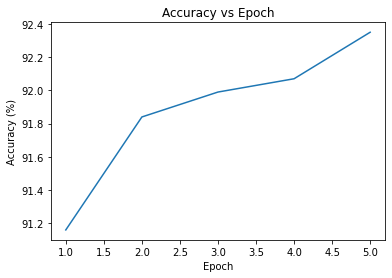

In [52]:
#Learning effects on number of epoch and accuracy for MLP
import matplotlib.pyplot as plt
epoch_list = [1, 2, 3, 4, 5]
accuracy_list = []
for e in epoch_list:
    print("\nEpoch =", e)

    model = MLP()   # reset model each time
    train(model, e)

    acc = test(model)
    accuracy_list.append(acc)

    print("Accuracy:", acc)

plt.plot(epoch_list, accuracy_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epoch")
plt.show()

<Figure size 432x288 with 0 Axes>